In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#  loading dataset
df = pd.read_csv('customer_shopping_behavior.csv')

In [3]:
# sample data
df.sample(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3068,3069,32,Female,Boots,Footwear,40,California,M,Indigo,Winter,4.2,No,Express,No,No,4,Debit Card,Weekly
3567,3568,32,Female,Scarf,Accessories,56,New Mexico,S,Silver,Summer,4.0,No,Next Day Air,No,No,26,Credit Card,Monthly
770,771,19,Male,Sneakers,Footwear,54,Vermont,M,Gray,Spring,3.3,Yes,Express,Yes,Yes,8,Credit Card,Annually
1977,1978,24,Male,Sandals,Footwear,49,Florida,M,Teal,Summer,2.6,No,Free Shipping,No,No,32,Bank Transfer,Annually
3378,3379,49,Female,Shorts,Clothing,75,Minnesota,L,Gold,Fall,4.5,No,Next Day Air,No,No,6,Cash,Quarterly


In [4]:
# dataset sahpe 
df.shape

(3900, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
# statistical info of numerical columns
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [7]:
# statistical info of categorical column
df.describe(include='object')

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Payment Method,Frequency of Purchases
count,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900
unique,2,25,4,50,4,25,4,2,6,2,2,6,7
top,Male,Blouse,Clothing,Montana,M,Olive,Spring,No,Free Shipping,No,No,PayPal,Every 3 Months
freq,2652,171,1737,96,1755,177,999,2847,675,2223,2223,677,584


# Data cleaning

In [8]:
# identifying missing values
df.isna().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [9]:
# Handling missing values by category median
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [10]:
# transforming column names into snake case
df.columns = df.columns.str.lower().str.replace(' ','_')
df.rename(columns={'purchase_amount_(usd)':'purchase_amount'},inplace=True)

In [11]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

# Feature Engineering

In [12]:
# creating age group column
lables = ['Young Adult','Adult','Middle-aged','senior']
age_group = pd.qcut(df['age'],q=4,labels=lables).values

In [13]:
df.insert(2,'age_group',value= age_group)

In [15]:
df['frequency_of_purchases'].value_counts().index

Index(['Every 3 Months', 'Annually', 'Quarterly', 'Monthly', 'Bi-Weekly',
       'Fortnightly', 'Weekly'],
      dtype='object', name='frequency_of_purchases')

In [34]:
# creating column purchase_frequency_days
frequency_mapping = {
    'Weekly': 7,
    'Fortnightly': 14,
    'Bi-Weekly': 14,
    'Monthly': 30,
    'Every 3 Months': 90,
    'Quarterly': 90,
    'Annually': 365
}

In [17]:
frequency_days = df['frequency_of_purchases'].map(frequency_mapping)

In [18]:
df.insert(17,'purchase_frequency_days',value=frequency_days.values)

In [19]:
df.columns

Index(['customer_id', 'age', 'age_group', 'gender', 'item_purchased',
       'category', 'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'purchase_frequency_days', 'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [20]:
# dropping column promo_code_used
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [21]:
df.drop(columns=['promo_code_used'],inplace=True)

In [22]:
pip install pymysql sqlalchemy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from sqlalchemy import create_engine

# MySQL connection
username = 'root'
password = 'Harsh@123'
host = 'localhost'
port = '3306'
database = 'customer'

import urllib.parse
from sqlalchemy import create_engine

# URL-encode the password to safely handle '@', ':', or '/' characters
safe_password = urllib.parse.quote_plus(password)

# Rebuild the engine using the encoded password
engine = create_engine(f"mysql+pymysql://{username}:{safe_password}@{host}:{port}/{database}")


table_name = "customer_data" 
df.to_sql(table_name,engine,if_exists='replace',index=False)

pd.read_sql("SELECT * FROM customer_data limit 5 ;",engine)

,customer_id,age,age_group,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,purchase_frequency_days,payment_method,frequency_of_purchases
0,1,55,Middle-aged,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,14,Venmo,Fortnightly
1,2,19,Young Adult,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,14,Cash,Fortnightly
2,3,50,Middle-aged,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,7,Credit Card,Weekly
3,4,21,Young Adult,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,7,PayPal,Weekly
4,5,45,Middle-aged,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,365,PayPal,Annually


In [24]:
df['purchase_frequency_days'].value_counts()

purchase_frequency_days
90     1147
14     1089
365     572
30      553
7       539
Name: count, dtype: int64

In [25]:
df

,customer_id,age,age_group,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,purchase_frequency_days,payment_method,frequency_of_purchases
0,1,55,Middle-aged,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,14,Venmo,Fortnightly
1,2,19,Young Adult,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,14,Cash,Fortnightly
2,3,50,Middle-aged,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,7,Credit Card,Weekly
3,4,21,Young Adult,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,7,PayPal,Weekly
4,5,45,Middle-aged,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,365,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Adult,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,32,7,Venmo,Weekly
3896,3897,52,Middle-aged,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,41,14,Bank Transfer,Bi-Weekly
3897,3898,46,Middle-aged,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,24,90,Venmo,Quarterly
3898,3899,44,Adult,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,24,7,Venmo,Weekly


# Outlier Detection

<Axes: >

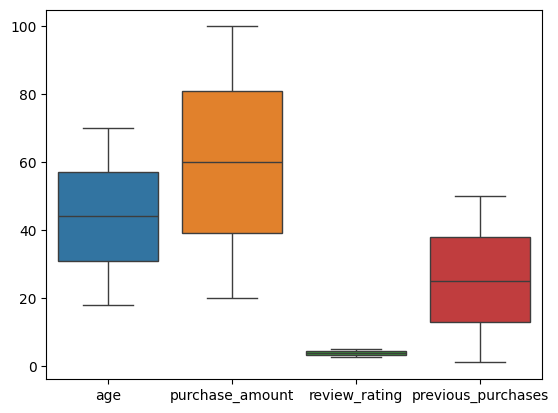

In [33]:
sns.boxplot(df[['age','purchase_amount','review_rating','previous_purchases']])